In [ ]:
# Import modules
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from scipy.spatial import Voronoi, voronoi_plot_2d
from shapely.geometry import box
from shapely.geometry import Polygon, Point
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from matplotlib.gridspec import GridSpec
from google.colab import files

In [ ]:
# Load data
watershed = gpd.read_file("enter_your_shapefile_name")
raingauge = gpd.read_file("enter_your_shapefile_name")

# Match CRS for raingauges
raingauge = raingauge.to_crs(watershed.crs)

# Load precip CSV
precip = pd.read_csv("enter_your_csv_name")
display(precip)

,DateTime,RG2,RG4,RG5,RG6,RG7,RG8,RG10,RG11,RG12,...,RG43,RG45,RG46,RG50,RG51,RG52,RG53,RG54,RG55,RG57
0,9/15/1981,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN
1,9/16/1981,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN
2,9/17/1981,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN
3,9/18/1981,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN
4,9/19/1981,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3290,9/18/1990,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3291,9/19/1990,2.032,0.000,0.000,0.000,1.016,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,11.430,9.144,4.826,0.000,0.000,0.000
3292,9/20/1990,5.334,4.826,3.556,3.810,4.064,3.810,2.794,4.064,4.064,...,5.842,4.826,3.810,4.318,4.318,4.064,4.318,4.572,4.572,4.064
3293,9/21/1990,14.732,15.494,16.256,12.192,14.986,10.922,10.414,11.176,10.668,...,8.382,9.906,11.176,16.002,17.018,16.256,14.732,16.510,12.192,12.954


In [ ]:
# ----------------------------------------
# Automatic CRS Selection

# Step 1: Ensure centroid is in geographic lat/lon (EPSG:4326)
watershed_ll = watershed.to_crs("EPSG:4326")
centroid = watershed_ll.geometry.iloc[0].centroid
lon, lat = centroid.x, centroid.y

# Step 2: Compute correct UTM zone
zone = int((lon + 180) // 6) + 1
utm_crs = f"EPSG:326{zone}" if lat >= 0 else f"EPSG:327{zone}"

# Step 3: Reproject watershed to UTM (meters)
watershed_proj = watershed.to_crs(utm_crs)

# Step 4: Buffer in meters
watershed_buffer_proj = watershed_proj.buffer(100000)

# Step 5: Convert back to original CRS
watershed_buffer = watershed_buffer_proj.to_crs(watershed.crs)

# Step 6: Get buffered extent
min_x_cty_tp, min_y_cty_tp, max_x_cty_tp, max_y_cty_tp = watershed_buffer.total_bounds

In [ ]:
#Get all combination of raingauges
precip = precip.drop([x for x in ['Row','DateTime'] if x in precip.columns], axis=1)
precip['whichgauges'] = precip[precip.columns.tolist()].apply(lambda x: x.isna().tolist(), axis=1)
display(precip)


,RG2,RG4,RG5,RG6,RG7,RG8,RG10,RG11,RG12,RG13,...,RG45,RG46,RG50,RG51,RG52,RG53,RG54,RG55,RG57,whichgauges
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal..."
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal..."
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal..."
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal..."
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3290,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,"[False, False, False, False, False, False, Fal..."
3291,2.032,0.000,0.000,0.000,1.016,0.000,0.000,0.000,0.000,1.016,...,0.000,0.000,0.000,11.430,9.144,4.826,0.000,0.000,0.000,"[False, False, False, False, False, False, Fal..."
3292,5.334,4.826,3.556,3.810,4.064,3.810,2.794,4.064,4.064,4.826,...,4.826,3.810,4.318,4.318,4.064,4.318,4.572,4.572,4.064,"[False, False, False, False, False, False, Fal..."
3293,14.732,15.494,16.256,12.192,14.986,10.922,10.414,11.176,10.668,16.764,...,9.906,11.176,16.002,17.018,16.256,14.732,16.510,12.192,12.954,"[False, False, False, False, False, False, Fal..."


In [ ]:
gauge_lists = precip['whichgauges']

# Convert inner lists to tuples and add to a set
unique_gauge_tuples = set(tuple(one_gauge_list) for one_gauge_list in gauge_lists)

# Convert unique tuples back to lists
unique_gauge_lists = [list(tup) for tup in unique_gauge_tuples]

unique_mapping = {item: i for i, item in enumerate(unique_gauge_tuples)}

# Number the original series
numbered_series = []
for sublist in gauge_lists:
    numbered_series.append(unique_mapping[tuple(sublist)])

#Add back into the precip array
precip['which_gauge_set'] = numbered_series

print(unique_gauge_lists)
display(precip)

[[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False], [False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, False, False, True, False, False, True, True]]


,RG2,RG4,RG5,RG6,RG7,RG8,RG10,RG11,RG12,RG13,...,RG46,RG50,RG51,RG52,RG53,RG54,RG55,RG57,whichgauges,which_gauge_set
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,NaN,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3290,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,"[False, False, False, False, False, False, Fal...",0
3291,2.032,0.000,0.000,0.000,1.016,0.000,0.000,0.000,0.000,1.016,...,0.000,0.000,11.430,9.144,4.826,0.000,0.000,0.000,"[False, False, False, False, False, False, Fal...",0
3292,5.334,4.826,3.556,3.810,4.064,3.810,2.794,4.064,4.064,4.826,...,3.810,4.318,4.318,4.064,4.318,4.572,4.572,4.064,"[False, False, False, False, False, False, Fal...",0
3293,14.732,15.494,16.256,12.192,14.986,10.922,10.414,11.176,10.668,16.764,...,11.176,16.002,17.018,16.256,14.732,16.510,12.192,12.954,"[False, False, False, False, False, False, Fal...",0


In [ ]:
display(unique_gauge_lists)

print('gap')

for gauge_set in unique_gauge_lists:
  gauge_set = [not value for value in gauge_set]
  print(gauge_set)

[[False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False],
 [False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  False,
  True,
  True,
  True,
  False,
  False,
  True,
  False,
  False,
  True,
  True]]

gap
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
[True, True, True, True, True, True, True, True, True, True, True, True, False, False, False, True, True, False, True, True, False, False]


In [ ]:
# -------------------------------------------------
# Standardize gauge ID column
# -------------------------------------------------
if "GAGE_NO" in raingauge.columns:
    raingauge = raingauge.rename(columns={"GAGE_NO": "RG"})
elif "RG" not in raingauge.columns:
    raise KeyError("No valid gauge identifier column found in raingauge.")

In [ ]:
frac_lists = []

for gauge_set in unique_gauge_lists:
  #Converts from 'is nan' to 'is a gauged value'
  gauge_set = [not value for value in gauge_set]
  #print(gauge_set)

  #Create the Thiessen values

  #Subset the raingauge list
  raingauge_subset = raingauge.loc[gauge_set, :]

  # Get minimum and maximum coordinate values of rainfall training points
  min_x_rain, min_y_rain, max_x_rain, max_y_rain = raingauge_subset.total_bounds

  # Use extent to create dummy points and add them to list of coordinates
  rain_coords = raingauge_subset.get_coordinates()
  rain_coords = rain_coords.values.tolist()
  coords_tp = rain_coords + [[min_x_cty_tp, min_y_cty_tp], [max_x_cty_tp, min_y_cty_tp],
                                 [max_x_cty_tp, max_y_cty_tp], [min_x_cty_tp, max_y_cty_tp]]

  # Compute Voronoi diagram
  tp = Voronoi(coords_tp)

  # Create empty list of hold Voronoi polygons
  tp_poly_list = []

  # Create a polygon for each region
  # 'regions' attribute provides a list of indices of the vertices (in the 'vertices' attribute) that make up the region
  # Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.Voronoi.html
  for region in tp.regions:

    # Ignore region if -1 is in the list (based on documentation)
    if -1 in region:

        # Return to top of loop
        continue

    # Otherwise, pass
    else:
        pass

    # Check that region list has values in it
    if len(region) != 0:

        # Create a polygon by using the region list to call the correct elements in the 'vertices' attribute
        tp_poly_region = Polygon(list(tp.vertices[region]))

        # Append polygon to list
        tp_poly_list.append(tp_poly_region)

    # If no values, return to top of loop
    else:
        continue

  # Create GeoDataFrame from list of polygon regions
  tp_polys = gpd.GeoDataFrame(tp_poly_list, columns = ['geometry'], crs = watershed.crs)

  # Clip polygon regions to the watershed boundary
  tp_polys_clipped = gpd.clip(tp_polys, watershed)

  # ADDED LINE — Reproject polygons to a projected CRS so areas are correct
  tp_polys_clipped = tp_polys_clipped.to_crs("EPSG:26911")

  # ALSO reproject raingauges to match polygons before spatial join
  raingauge_subset_proj = raingauge_subset.to_crs("EPSG:26911")

  # Spatial join
  tp_polys_clipped_values = gpd.sjoin(
    raingauge_subset_proj,
    tp_polys_clipped,
    how="right",
    predicate="within"
  ).drop("index_left", axis=1)

  # Correct area calculation in square kilometers
  tp_polys_clipped_values['area_sq_km'] = tp_polys_clipped_values.geometry.area / 1000000

  # Calculate the sum of all polygon areas
  total_area_sqkm = tp_polys_clipped_values['area_sq_km'].sum()

  # Get fractional area of each thiessen polygon
  tp_polys_clipped_values['area_frac'] = tp_polys_clipped_values['area_sq_km'] / total_area_sqkm

  # Display head of attribute table
  print("Attribute Table: Thiessen Polygon Interpolated Values")
  #display(tp_polys_clipped_values.head())

  # Append selected columns to frac_lists
  frac_lists.append(tp_polys_clipped_values[['geometry', 'area_frac', 'RG']])

#display(frac_lists)



Attribute Table: Thiessen Polygon Interpolated Values
Attribute Table: Thiessen Polygon Interpolated Values


In [ ]:
for i, item in enumerate(frac_lists):
    item2 = item.copy()
    # Remove 'RG' prefix but keep letters
    item2['RG'] = item2['RG'].str.replace('RG', '')
    # Sort alphabetically
    item2 = item2.sort_values(by='RG')
    display(item2)
    frac_lists[i] = item2

,geometry,area_frac,RG
19,"POLYGON ((3033403.671 4145355.759, 3033129.292...",0.027215,10
16,"POLYGON ((3033403.671 4145355.759, 3033245.984...",0.023864,11
17,"POLYGON ((3034010.533 4146339.517, 3034039.838...",0.020901,12
5,"POLYGON ((3028098.861 4142871.388, 3028950.491...",0.032376,13
10,"POLYGON ((3029461.663 4142162.301, 3029138.866...",0.048081,14
8,"POLYGON ((3027777.372 4139793.292, 3027747.176...",0.115297,2
11,"POLYGON ((3029765.59 4145038.969, 3030576.132 ...",0.055811,4
6,"POLYGON ((3028002.574 4142935.323, 3028042.604...",0.029073,41
3,"POLYGON ((3031798.928 4146027.411, 3030123.502...",0.037152,43
21,"POLYGON ((3033110.452 4146648.072, 3033197.503...",0.010037,45


,geometry,area_frac,RG
4,"POLYGON ((3032466.811 4144247.039, 3032110.654...",0.083063,10
7,"POLYGON ((3034187.981 4145461.683, 3034064.599...",0.031935,11
9,"MULTIPOLYGON (((3033624.781 4146605.303, 30336...",0.031862,12
1,"POLYGON ((3029138.866 4142342.359, 3028433.231...",0.032376,13
12,"POLYGON ((3030241.619 4142631.241, 3030222.992...",0.063474,14
3,"POLYGON ((3028098.861 4142871.388, 3028433.231...",0.115297,2
10,"POLYGON ((3029765.59 4145038.969, 3030576.132 ...",0.055811,4
11,"POLYGON ((3029181.403 4143881.924, 3028950.491...",0.029073,41
5,"POLYGON ((3031321.941 4144155.832, 3030872.247...",0.072517,5
13,"POLYGON ((3030914.14 4143445.102, 3030241.619 ...",0.025741,50


In [ ]:
display(frac_lists)

[                                             geometry  area_frac  RG
 19  POLYGON ((3033403.671 4145355.759, 3033129.292...   0.027215  10
 16  POLYGON ((3033403.671 4145355.759, 3033245.984...   0.023864  11
 17  POLYGON ((3034010.533 4146339.517, 3034039.838...   0.020901  12
 5   POLYGON ((3028098.861 4142871.388, 3028950.491...   0.032376  13
 10  POLYGON ((3029461.663 4142162.301, 3029138.866...   0.048081  14
 8   POLYGON ((3027777.372 4139793.292, 3027747.176...   0.115297   2
 11  POLYGON ((3029765.59 4145038.969, 3030576.132 ...   0.055811   4
 6   POLYGON ((3028002.574 4142935.323, 3028042.604...   0.029073  41
 3   POLYGON ((3031798.928 4146027.411, 3030123.502...   0.037152  43
 21  POLYGON ((3033110.452 4146648.072, 3033197.503...   0.010037  45
 1   MULTIPOLYGON (((3034582.204 4146492.43, 303459...   0.008305  46
 4   POLYGON ((3031976.006 4144207.922, 3031321.941...   0.057232   5
 9   POLYGON ((3029748.193 4143378.095, 3030576.132...   0.025644  50
 7   POLYGON ((30284

Use a spatial join to assign the rainfall values to their associated Thiessen polygon.

In [ ]:
# Get all rain gauge columns
gauge_columns = [col for col in precip.columns if col.startswith('RG')]

# Build weights dictionary for each gauge set
weights_dict = {}
for i, frac_df in enumerate(frac_lists):
    gauges = frac_df['RG'].tolist()  # Use 'RG' column
    weights = np.zeros(len(gauge_columns))

    for j, col in enumerate(gauge_columns):
        gauge_name = col  # Keep full name
        if gauge_name in gauges:
            val = frac_df.loc[frac_df['RG'] == gauge_name, 'area_frac'].values
            if len(val) == 1:
                weights[j] = val[0]
            else:
                print(f"Warning: Gauge {gauge_name} not found in frac_df {i}")
    weights_dict[i] = weights

# Convert precipitation DataFrame to numpy array
precip_values = precip[gauge_columns].to_numpy(dtype=float)

# Initialize weighted precipitation array
weighted_precip = np.full(precip.shape[0], np.nan)

# Compute weighted precipitation row by row
for i in range(precip.shape[0]):
    weight_idx = precip.iloc[i]['which_gauge_set']
    weights = weights_dict[weight_idx]

    row_values = precip_values[i, :]
    # Ignore NaNs
    valid_mask = ~np.isnan(row_values)
    values = row_values[valid_mask]
    wts = weights[valid_mask]

    # Count how many gauges have non-zero precipitation
    non_zero_count = np.sum(values != 0)

    if non_zero_count == 0:
        # Both gauges = 0
        weighted_precip[i] = 0.0
    elif non_zero_count == 1:
        # Only one gauge has precipitation → use that value
        weighted_precip[i] = values[values != 0][0]
    else:
        # Both gauges > 0 → weighted average using area_frac
        sum_weights = np.sum(wts)
        if sum_weights > 0:
            weighted_precip[i] = np.sum(values * wts) / sum_weights
        else:
            # Fallback if weights somehow sum to 0
            weighted_precip[i] = np.mean(values)

# Add weighted precipitation to DataFrame
precip['weighted_precip'] = weighted_precip

In [ ]:
display(precip)

,RG2,RG4,RG5,RG6,RG7,RG8,RG10,RG11,RG12,RG13,...,RG50,RG51,RG52,RG53,RG54,RG55,RG57,whichgauges,which_gauge_set,weighted_precip
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.000000
1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.000000
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.000000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.000000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,NaN,0.000,0.000,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3290,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,"[False, False, False, False, False, False, Fal...",0,0.000000
3291,2.032,0.000,0.000,0.000,1.016,0.000,0.000,0.000,0.000,1.016,...,0.000,11.430,9.144,4.826,0.000,0.000,0.000,"[False, False, False, False, False, False, Fal...",0,1.420091
3292,5.334,4.826,3.556,3.810,4.064,3.810,2.794,4.064,4.064,4.826,...,4.318,4.318,4.064,4.318,4.572,4.572,4.064,"[False, False, False, False, False, False, Fal...",0,4.364182
3293,14.732,15.494,16.256,12.192,14.986,10.922,10.414,11.176,10.668,16.764,...,16.002,17.018,16.256,14.732,16.510,12.192,12.954,"[False, False, False, False, False, False, Fal...",0,13.762182


Combine with timestamps

In [ ]:
# Read in original precip csv
precip_original = pd.read_csv("enter_your_csv_name")

# Add the DateTime column back
precip['DateTime'] = precip_original['DateTime']

# Optional: move DateTime to the first column
cols = ['DateTime'] + [c for c in precip.columns if c != 'DateTime']
precip = precip[cols]

# Display first few rows
display(precip.head())

,DateTime,RG2,RG4,RG5,RG6,RG7,RG8,RG10,RG11,RG12,...,RG50,RG51,RG52,RG53,RG54,RG55,RG57,whichgauges,which_gauge_set,weighted_precip
0,9/15/1981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.0
1,9/16/1981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.0
2,9/17/1981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.0
3,9/18/1981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.0
4,9/19/1981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,NaN,NaN,"[False, False, False, False, False, False, Fal...",1,0.0


Plot Results

In [ ]:
print("Watershed CRS:", watershed.crs)
print("Raingauge CRS:", raingauge.crs)
for i, frac_df in enumerate(frac_lists):
    print(f"Frac DF {i} CRS:", frac_df.crs)

Watershed CRS: EPSG:4269
Raingauge CRS: EPSG:4269
Frac DF 0 CRS: EPSG:26911
Frac DF 1 CRS: EPSG:26911


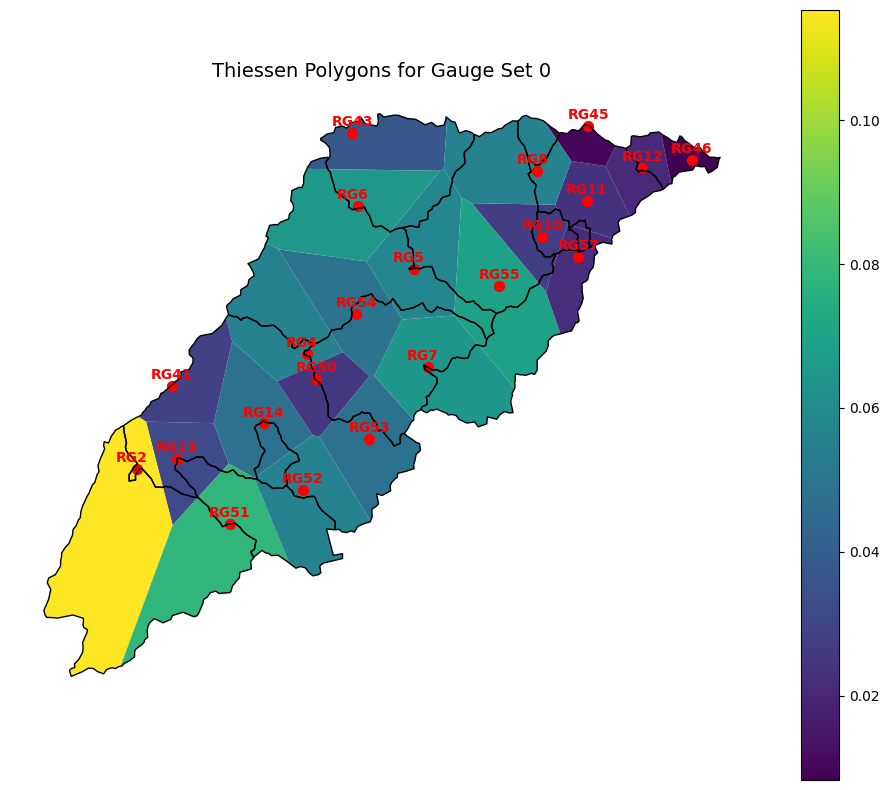

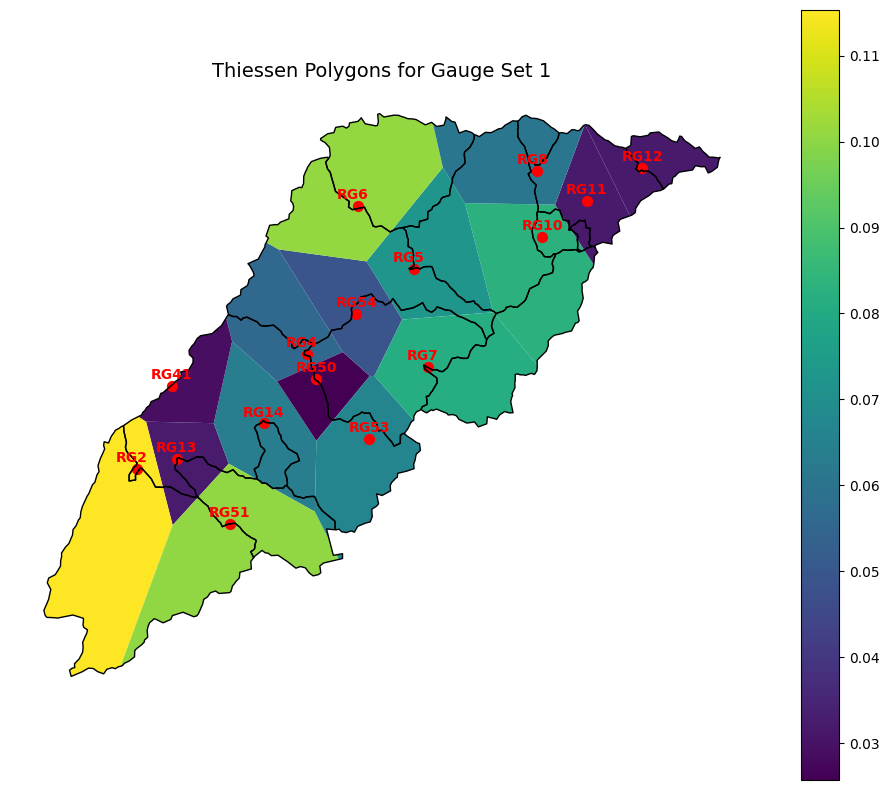

In [ ]:
# Ensure Gauge_ID exists as a string for matching (do NOT convert to int)
if 'Gauge_ID' not in raingauge.columns:
    raingauge['Gauge_ID'] = raingauge['RG'].str.replace('RG','').str.strip()

for i, frac_df in enumerate(frac_lists):
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # Reproject watershed and raingauges to match frac_df CRS
    watershed_plot = watershed.to_crs(frac_df.crs)
    raingauge_plot = raingauge.to_crs(frac_df.crs)

    # Plot watershed boundary
    watershed_plot.boundary.plot(ax=ax, color='black', linewidth=1)

    # Plot Thiessen polygons colored by area fraction
    frac_df.plot(column='area_frac', ax=ax, cmap='viridis', legend=True)

    # Plot active gauges
    gauges_active = frac_df['RG'].tolist()
    raingauge_subset = raingauge_plot[raingauge_plot['Gauge_ID'].isin(gauges_active)]

    if not raingauge_subset.empty:
        raingauge_subset.plot(ax=ax, color='red', markersize=50)

        # Annotate gauges
        for idx, row in raingauge_subset.iterrows():
            ax.annotate(
                f"RG{row['Gauge_ID']}",
                xy=(row.geometry.x, row.geometry.y),
                xytext=(-15, 5), textcoords="offset points",
                fontsize=10,
                color='red',
                fontweight='bold'
            )

    ax.set_title(f'Thiessen Polygons for Gauge Set {i}', fontsize=14)
    ax.set_axis_off()
    plt.show()

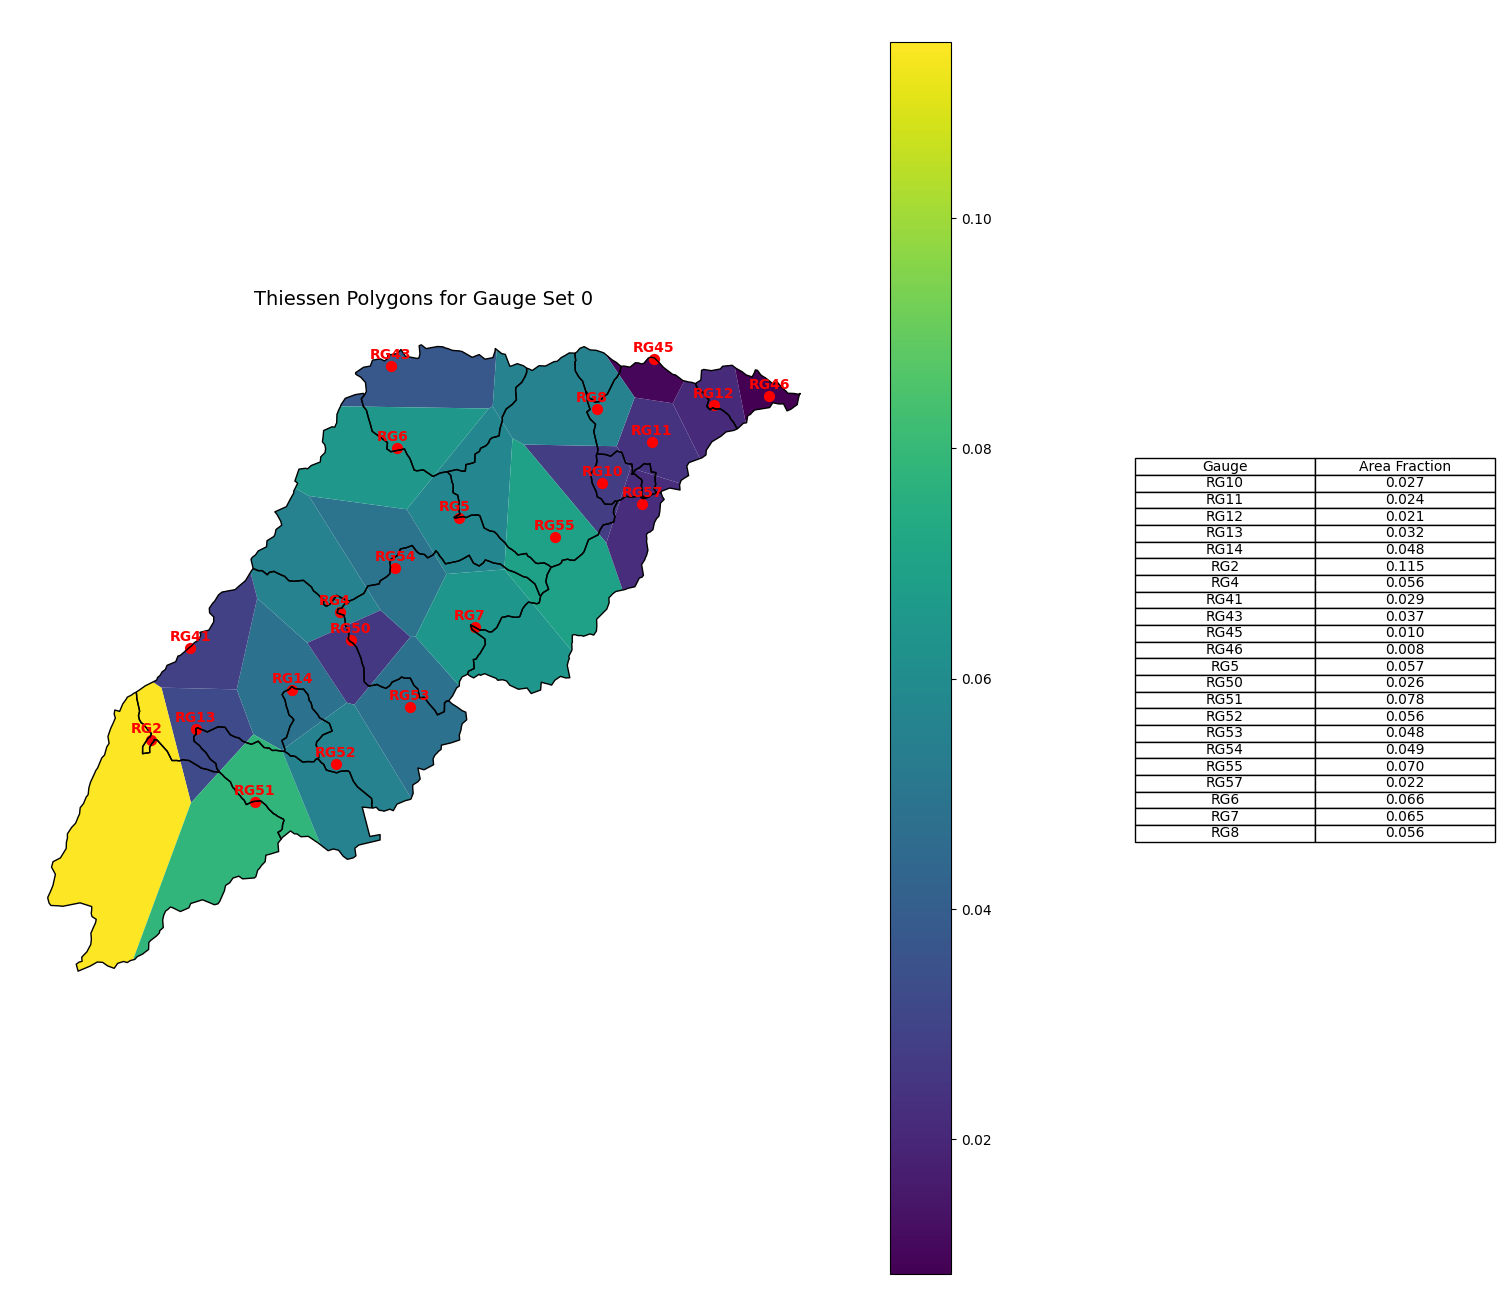

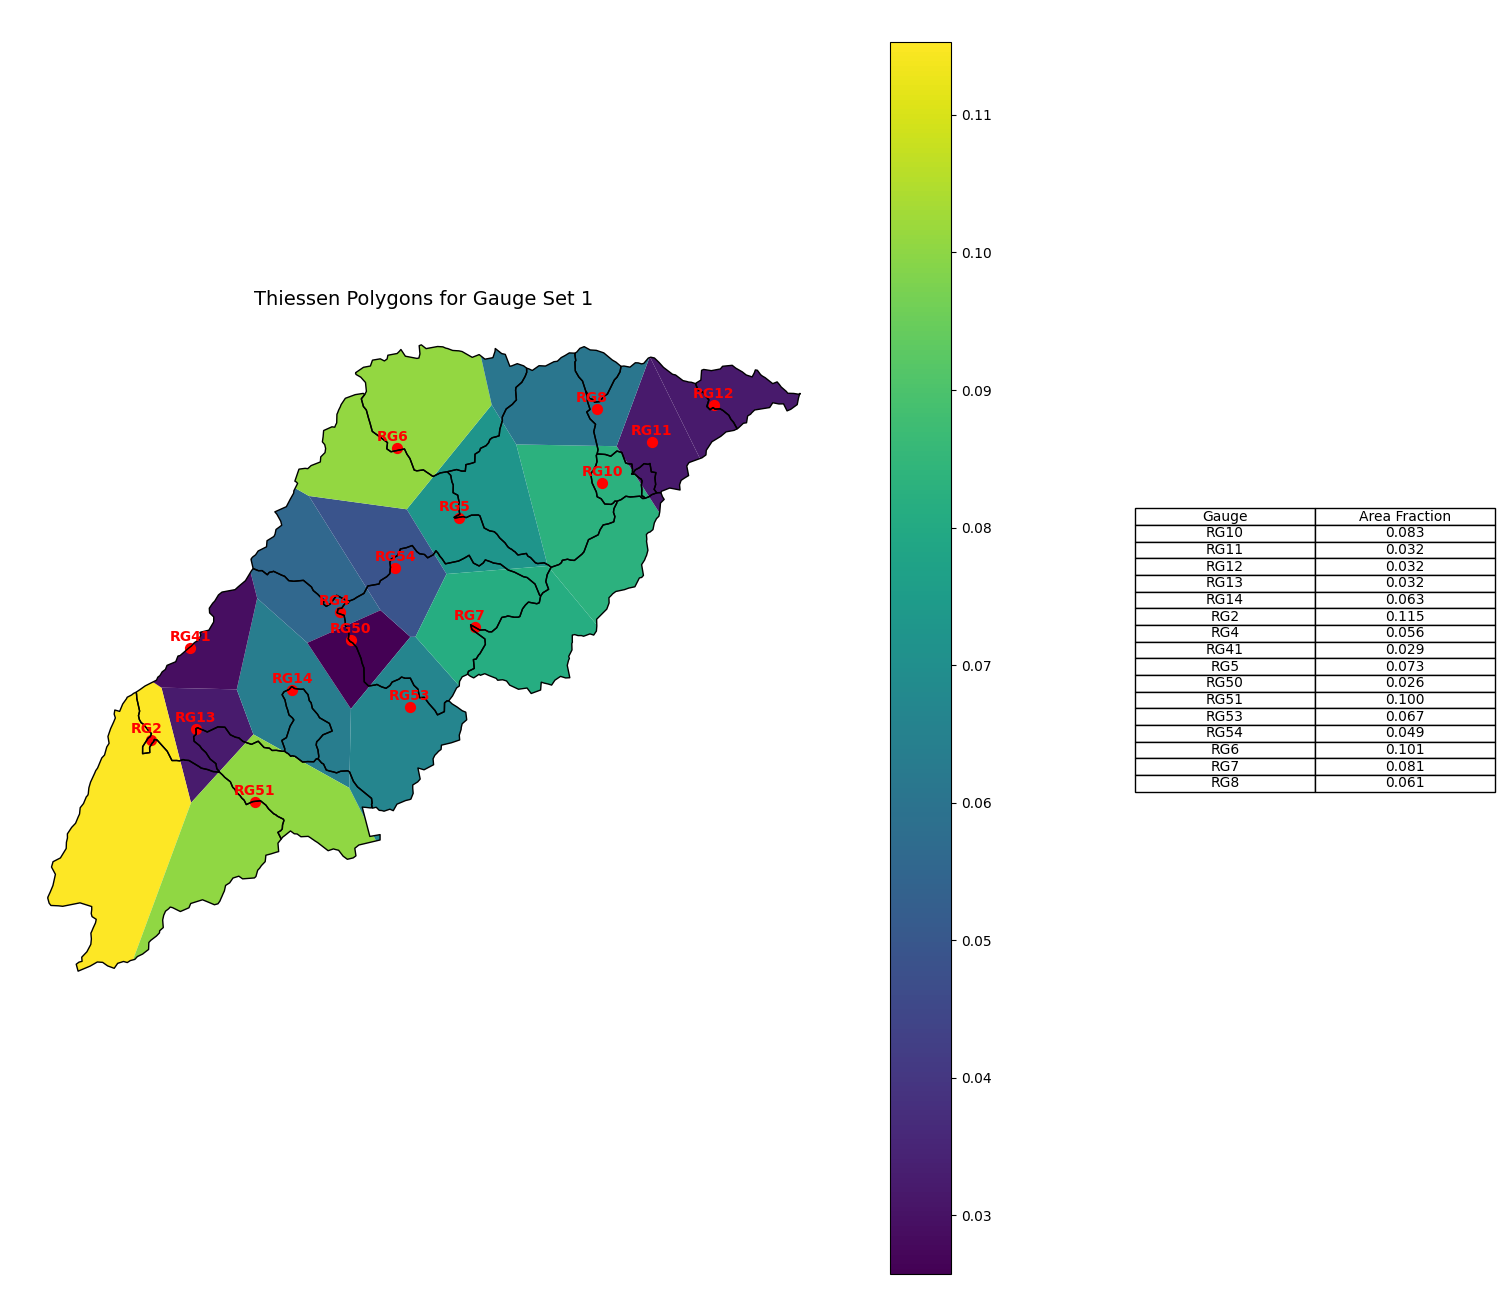

In [ ]:
# Ensure Gauge_ID exists as a string for matching (do NOT convert to int)
if 'Gauge_ID' not in raingauge.columns:
    raingauge['Gauge_ID'] = raingauge['RG'].str.replace('RG','').str.strip()

for i, frac_df in enumerate(frac_lists):
    fig, ax = plt.subplots(1, 1, figsize=(18, 16))  # wider figure to fit table

    # Reproject watershed and raingauge to match frac_df CRS
    watershed_plot = watershed.to_crs(frac_df.crs)
    raingauge_plot = raingauge.to_crs(frac_df.crs)

    # Plot watershed boundary
    watershed_plot.boundary.plot(ax=ax, color='black', linewidth=1)

    # Plot Thiessen polygons colored by area fraction
    frac_df.plot(column='area_frac', ax=ax, cmap='viridis', legend=True)

    # Plot active gauges
    gauges_active = frac_df['RG'].tolist()
    raingauge_subset = raingauge_plot[raingauge_plot['Gauge_ID'].isin(gauges_active)]

    if not raingauge_subset.empty:
        raingauge_subset.plot(ax=ax, color='red', markersize=50)

        # Annotate gauges by ID (bold)
        for idx, row in raingauge_subset.iterrows():
            ax.annotate(
                f"RG{row['Gauge_ID']}",
                xy=(row.geometry.x, row.geometry.y),
                xytext=(-15, 5), textcoords="offset points",
                fontsize=10,
                color='red',
                fontweight='bold'
            )

    # Create table data: Gauge | Area Fraction
    table_data = [[f"RG{g}", f"{af:.3f}"] for g, af in zip(frac_df['RG'], frac_df['area_frac'])]
    col_labels = ["Gauge", "Area Fraction"]

    # Adjust figure and place table
    fig.subplots_adjust(right=0.7)  # leave space for table
    table_ax = fig.add_axes([0.75, 0.1, 0.2, 0.8])  # [left, bottom, width, height]
    table_ax.axis('off')
    table_ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')

    ax.set_title(f'Thiessen Polygons for Gauge Set {i}', fontsize=14)
    ax.set_axis_off()
    plt.show()